# Persistence — the closure hazard with duration dependence

How long does an arbitrage gap, once open, stay open? The closure branch of the
[existence equation](model_existence.ipynb) *already* answers this as a **discrete-time grouped
hazard**: restricting to `gap_lag > 0` and asking whether `D_t = 1` is, block by block, one
at-risk interval per row — "did the open spell survive this block?". The one thing the plain
closure hazard cannot see is **elapsed time**: every block of a spell is treated alike, whether it
is the spell's 1st or 8th.

This notebook adds that missing piece — `spell_duration`, the number of blocks the spell has
already survived (predetermined as of the block's own outcome) — turning the closure hazard into a
**duration-dependent** one (Wooldridge Ch. 20). One new covariate, the same estimator, 100 % of the
existing pipeline. All logic lives in `arblib.estimation`; this notebook only calls it.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd

from arblib import estimation as est
from arblib.config import STUDY as S

panel = est.load_panel(S)
print("panel:", panel.shape)

panel: (4725, 28)


## Build the closure risk set

`build_risk_set(..., condition="closure")` keeps the rows where a gap is open at `t-1`
(`gap_lag > 0`) with outcome `D_t` = "the spell survived this block". Each row already carries the
predetermined `spell_duration` (spell age as of `t-1`, stamped once on the panel by
`add_spell_columns`) and a `spell_id` identifying the ongoing spell — the one open at `t-1`, so
consecutive within-spell rows, including the closing block, share a cluster.

In [2]:
clo = est.build_risk_set(panel, quantile=0.2, condition="closure")
clo["spell_duration"].value_counts().sort_index()

q20: dropping 10 pool pairs with no D variation (uninformative under pair FE): ['uniswap_2_vs_pancake_2', 'uniswap_2_vs_uniswap_3', 'uniswap_2_vs_uniswap_4', 'uniswap_3_vs_pancake_1', 'uniswap_3_vs_pancake_2', 'uniswap_3_vs_uniswap_4', 'uniswap_3_vs_uniswap_5', 'uniswap_4_vs_pancake_1', 'uniswap_4_vs_pancake_2', 'uniswap_4_vs_uniswap_5']
closure: dropping 4 pairs: ['uniswap_1_vs_pancake_2', 'uniswap_1_vs_uniswap_3', 'uniswap_1_vs_uniswap_4', 'uniswap_2_vs_uniswap_5']
closure: (225, 17) | D mean: 0.5378 | pairs: 7 | spell_duration max: 10


spell_duration
1.0     101
2.0      55
3.0      32
4.0      18
5.0       8
6.0       6
7.0       2
8.0       1
9.0       1
10.0      1
Name: count, dtype: int64

In [3]:
CONT = ["gap_lag", "log_base_fee", "gas_util_lag", "tip_p90_lag",
        "mev_lag", "freq_lag", "log_vol", "dlogL_lag", "spell_duration"]
clo_c = est.center_continuous(clo, CONT)

dur = est.fit_hazard_logit(clo_c, est.CLOSURE_DURATION_TERMS, cluster="pair")
print(dur.summary())

                           Logit Regression Results                           
Dep. Variable:                      D   No. Observations:                  225
Model:                          Logit   Df Residuals:                      209
Method:                           MLE   Df Model:                           15
Date:                Wed, 05 Aug 2026   Pseudo R-squ.:                 0.08219
Time:                        13:02:21   Log-Likelihood:                -142.55
converged:                       True   LL-Null:                       -155.32
Covariance Type:              cluster   LLR p-value:                   0.04324
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -0.4667      0.465     -1.004      0.315      -1.378       0.444
C(pair)[T.uniswap_1_vs_pancake_1]     0.8187      0.243      3

In [4]:
clo_c

,pair,evt_block_number,evt_block_time,D,gap_lag,log_base_fee,gas_util_lag,tip_p90_lag,mev_lag,freq_lag,log_vol,dlogL_lag,spell_duration,hour,dow,week,spell_id
0,pancake_1_vs_pancake_2,24133440,2025-12-31 15:15:35+00:00,1.0,0.050821,0.144253,-0.048386,0.129292,2.174483,-0.555475,0.109875,0.000203,-1.204444,15,2,1,pancake_1_vs_pancake_2_q20_1
1,pancake_1_vs_pancake_2,24133441,2025-12-31 15:15:47+00:00,0.0,0.050821,0.051595,-0.358323,-0.175538,2.107817,-0.583517,0.109875,0.000203,-0.204444,15,2,1,pancake_1_vs_pancake_2_q20_1
2,pancake_1_vs_pancake_2,24133473,2025-12-31 15:22:11+00:00,0.0,-0.428525,0.105390,-0.019658,0.129292,0.717000,-0.609334,0.043346,0.000203,-1.204444,15,2,1,pancake_1_vs_pancake_2_q20_3
3,pancake_1_vs_pancake_2,24133545,2025-12-31 15:36:35+00:00,1.0,-1.626893,0.036869,0.207897,0.129292,0.629052,-0.534073,-0.023721,0.000203,-1.204444,15,2,1,pancake_1_vs_pancake_2_q20_5
4,pancake_1_vs_pancake_2,24133546,2025-12-31 15:36:47+00:00,1.0,-0.969956,-0.043718,-0.314046,-1.095734,0.562753,-0.531248,-0.023721,0.000203,-0.204444,15,2,1,pancake_1_vs_pancake_2_q20_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,uniswap_5_vs_pancake_2,24133597,2025-12-31 15:46:59+00:00,0.0,0.166068,-0.204996,0.315974,-0.074848,-0.656350,-0.285678,-0.058180,0.000203,-0.204444,15,2,1,uniswap_5_vs_pancake_2_q20_21
221,uniswap_5_vs_pancake_2,24133630,2025-12-31 15:53:35+00:00,1.0,-1.797817,-0.088783,0.070718,-0.301735,-1.126973,-0.261568,-0.134037,0.000203,-1.204444,15,2,1,uniswap_5_vs_pancake_2_q20_23
222,uniswap_5_vs_pancake_2,24133631,2025-12-31 15:53:47+00:00,1.0,-1.797817,-0.145965,-0.226654,0.129292,-1.193640,-0.308564,-0.134037,0.000203,-0.204444,15,2,1,uniswap_5_vs_pancake_2_q20_23
223,uniswap_5_vs_pancake_2,24133632,2025-12-31 15:53:59+00:00,0.0,-1.797817,-0.050798,0.395024,0.129292,-1.260307,-0.352530,-0.134037,0.000203,0.795556,15,2,1,uniswap_5_vs_pancake_2_q20_23


In [5]:
est.average_marginal_effects(dur, est.CLOSURE_DURATION_TERMS)

,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
gap_lag,0.002420,0.008141,0.297259,0.766269,-0.013537,0.018377
log_base_fee,0.673998,0.244384,2.757945,0.005817,0.195014,1.152982
gas_util_lag,0.066194,0.079708,0.830447,0.406286,-0.090032,0.222419
tip_p90_lag,-0.082989,0.106422,-0.779812,0.435502,-0.291573,0.125594
mev_lag,-0.073919,0.044215,-1.671823,0.094559,-0.160579,0.012740
freq_lag,-0.236219,0.209736,-1.126268,0.260052,-0.647295,0.174856
log_vol,0.682452,0.555354,1.228859,0.219125,-0.406022,1.770927
dlogL_lag,-3.971043,2.669270,-1.487689,0.136833,-9.202716,1.260629
spell_duration,-0.038068,0.013265,-2.869845,0.004107,-0.064067,-0.012069


## Spell-level view — Kaplan–Meier survival (lifelines)

Everything above is a *block-level* at-risk table (one row per open block). The classic survival
view takes the **spell** as the unit, so the dataframe has to be reshaped. `build_spell_table`
collapses the panel's canonical spells (`spell_id` / `spell_duration` from `add_spell_columns`) into
one row per spell:

- `duration` — the spell length in blocks (its final `spell_duration`);
- `observed` — lifelines' `event_observed`: `1` if closure is seen (the run is followed by a
  `Gap == 0` block), `0` if the spell is **right-censored** (its last block is the pair's last block
  in the window, so its true length is unknown).

That `observed` flag is the one thing the block panel never made explicit — the reshape is exactly
what turns "rows that just stop" into a proper censoring indicator. It is descriptive (no fixed
effects, no pair screening), so it keeps every spell across all pairs.

In [6]:
spells = est.build_spell_table(panel, quantile=0.2)
spells.head()

spells: 116 | closed: 116 | censored: 0 | left-truncated: 3 | median duration: 1.0


,pair,onset_block,last_block,duration,observed,left_truncated
0,pancake_1_vs_pancake_2,24133439,24133440,2,1,False
1,pancake_1_vs_pancake_2,24133472,24133472,1,1,False
2,pancake_1_vs_pancake_2,24133544,24133546,3,1,False
3,pancake_1_vs_pancake_2,24133553,24133554,2,1,False
4,pancake_1_vs_pancake_2,24133556,24133556,1,1,False


Fit the Kaplan–Meier estimator on `(duration, observed)` and read off
`S(t) = P(spell still open after t blocks)`. In this one-hour window nothing is censored (no spell
outlives the extraction), so the curve is the raw empirical survival — but the identical call handles
right-censoring unchanged on a longer sample.

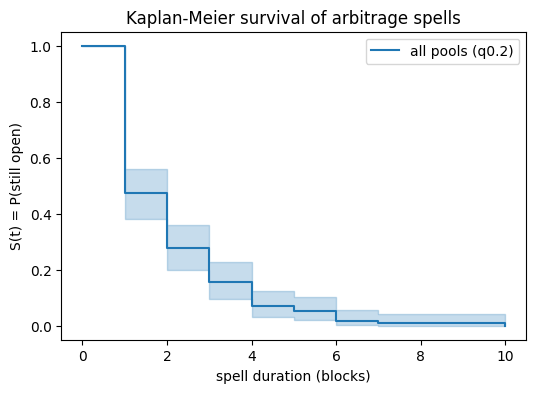

median survival (blocks): 1.0


,all pools (q0.2),all pools (q0.2)_lower_0.95,all pools (q0.2)_upper_0.95
timeline,,,
0.0,1.0000,1.0000,1.0000
1.0,0.4741,0.3811,0.5614
2.0,0.2759,0.1981,0.3590
3.0,0.1552,0.0963,0.2268
4.0,0.0690,0.0323,0.1246
5.0,0.0517,0.0212,0.1026
6.0,0.0172,0.0034,0.0553
7.0,0.0086,0.0008,0.0427
10.0,0.0000,0.0000,0.0000


In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(spells["duration"], event_observed=spells["observed"], label="all pools (q0.2)")

ax = kmf.plot_survival_function(figsize=(6, 4))
ax.set_xlabel("spell duration (blocks)"); ax.set_ylabel("S(t) = P(still open)")
ax.set_title("Kaplan-Meier survival of arbitrage spells")
plt.show()

print("median survival (blocks):", kmf.median_survival_time_)
kmf.survival_function_.join(kmf.confidence_interval_).round(4)